# Entropie

Deze mag Roel doen


entropie temperatuur uitwisseling met de omgeving. 

twee gekoppelde systemen

## Doelen

In de hoofdstukken 5 en 6 van het boek wordt er verder ingegaan op de reversibiliteit van processen. De klassieke mechanica eist alleen behoud van energie en impuls, maar er is geen richtingsvoorkeur in processen. Dat is in strijd met je dagelijkse ervaring, waarbij je van een videoopname vrijwel altijd kan zeggen of deze vooruit of achteruit wordt gespeeld. 

Deze richtingsvoorkeur wordt het best gemodelleerd door de entropie. Dit is een kwantitatieve grootheid die vaak een beetje mysterieus wordt gevonden. In dit werkblad zullen we kijken of we wat meer over deze entropie te weten kunnen komen.

In dit werkblad komen de volgende onderdelen langs:

- We herhalen de belangrijke stukken code met gekozen constanten en het gedrag van deeltjes.
- We introduceren een nieuwe klasse voor het beheersvolume die de reeds ontwikkelde functies bevat.
- We controleren of deze code gelijkwaardige resultaten geeft als de code in voorgaande werkbladen.
- We bekijken een ingewikkelder modelsysteem van gekoppelde zuigers en kijken hier naar verschillende processen.
- We nemen een reversibele en een niet-reversibele route en kijken naar het verschil in entropie.

## Laden van eerdere code

Net als bij de eerdere simulaties, gaan we uit van dezelfde set van constanten. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.optimize import curve_fit

BOX_SIZE_0 = 10                # Hoogte en breedte startvolume
N = 40                         # Aantal deeltjes
V_0 = 1                        # Startsnelheid van deeltjes
RADIUS = 0.1                   # Straal van moleculen
DT = 0.3 * RADIUS / V_0        # Tijdstap om geen botsing te missen
V_PISTON_0 = -0.1              # Startsnelheid van zuiger 
# (negatief betekent zowel links als rechts naar binnen gericht)

En maken we daarnaast ook gebruik van een klasse die het gedrag van deeltjes omschrijft:

In [ ]:
class ParticleClass:
    def __init__(self, m, v, r, R):
        """ maakt een deeltje (constructor) """
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = R

    def update_position(self):
        """ verandert positie voor één tijdstap """
        self.r += self.v * DT 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)
    
def collide_detection(p1: ParticleClass, p2: ParticleClass) -> bool:
    """ Geeft TRUE als de deeltjes overlappen """
    return np.linalg.norm(p1.r - p2.r) < (p1.R + p2.R)


def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

## Het beheersvolume

In het boek wordt er vaak in het Engels gesproken over een 'control volume'. Dit is een reëel of denkbeeldig volume waaraan een aantal macroscopische eigenschappen worden toegekend. Het Nederlandse woord hiervoor is 'beheersvolume'. Veel van de functies die we tot nu toe hebben ontwikkeld gaan over eigenschappen en gedrag van een dergelijk beheersvolume. Om de code dus beter te structureren, maken we hier een klasse voor. Dit maakt het vooral makkelijk om met twee beheersvolumes te rekenen en dat zal later in dit werkblad ons doel zijn.

Als je de code hieronder vergelijkt met die van de vorige werkbladen, zal je een aantal zaken opvallen: 

- Elke functie heeft een parameter 'self' gekregen. Daarmee begrijpt Python dat het om een functie van de klasse gaat.
- De variabelen die als `global` stonden vermeld zijn nu een variabele van de klasse en hoeven dus niet meer gedeclareerd te worden in elke functie. Ze moeten in de code wel telkens worden voorafgegaan door het woord `self`, om dit duidelijk te maken. 
- Om de eigenschappen `heat`, `work` en `pressure` alleen te laten lezen en niet te laten schrijven, maken we gebruik van een Python conventie waarbij we een 'geheime' variabele gebruiken die wordt voorafgegaan door een laag liggend streepje '_' (Engels: underscore). 

In [ ]:
class ControlVolume:
    def __init__(self, length, height, N, v_piston, set_temp):
        """ maakt een beheersvolume (constructor) """
        self.length = length
        self.height = height 
        self.v_piston = v_piston
        self.set_temp = set_temp
        self.particles = []
        self._work = 0.0
        self._heat = 0.0
        self._impulse_out = 0.0
        self._pressure = 0.0
        for _ in range(N):
            vx = np.random.uniform(-V_0, V_0)
            vy = np.random.choice([-1, 1]) * np.sqrt(V_0**2 - vx**2)        
            x = np.random.uniform(-self.length/2 + RADIUS, self.length/2 - RADIUS)
            y = np.random.uniform(-self.height/2 + RADIUS, self.height/2 - RADIUS)
            self.particles.append(ParticleClass(m=1.0, v=[vx, vy], r=[x, y], R=RADIUS))

    def handle_collisions(self) -> None:
        """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
        num_particles = len(self.particles)
        for i in range(num_particles):
            for j in range(i+1, num_particles):
                if collide_detection(self.particles[i], self.particles[j]):
                    particle_collision(self.particles[i], self.particles[j])

    def piston_collision(self, particle: ParticleClass) -> None:
        """ verzorgen van botsingen met wand links en rechts, die als zuiger kunnen bewegen """
        if abs(particle.r[0]) + particle.R > self.length / 2:
            particle.r[0] = np.sign(particle.r[0]) * (self.length/2 - particle.R)
            piston_velocity = np.sign(particle.r[0]) * self.v_piston
            relative_velocity = particle.v[0] - piston_velocity  # stelsel zuiger
            particle.v[0] = -relative_velocity + piston_velocity # stelsel waarnemer
            self._impulse_out += 2 * particle.m * abs(relative_velocity)
            self._work += 2 * particle.m * relative_velocity * piston_velocity

    def thermostat_collision(self, particle: ParticleClass) -> None:
        """ verzorgen van botsingen met wand boven en onder, die als thermostaat kunnen werken """
        if abs(particle.r[1]) + particle.R > self.height / 2:
            temp_factor = (self.set_temp/self.temperature) if self.set_temp > 0 else 1.0
            particle.r[1] = np.sign(particle.r[1]) * (self.height/2 - particle.R)
            self._impulse_out += abs(particle.momentum[1]) * (1 + temp_factor**0.5) 
            self._heat += particle.kin_energy * (temp_factor - 1)
            particle.v *= temp_factor**0.5
            particle.v[1] *= -1

    def handle_walls(self) -> None:
        """ verzorgen van alle botsingen met wanden en aanpassen waarde voor druk """
        self._impulse_out = 0.0
        for p in self.particles:
            self.piston_collision(p)
            self.thermostat_collision(p)
        self._pressure = 0.95 * self._pressure + 0.05 * self._impulse_out / (self.circumference * DT)

    def take_time_step(self) -> None:
        self.length += 2 * self.v_piston * DT # zowel links als rechts zuiger
        for p in self.particles:
            p.update_position()
        self.handle_collisions()
        self.handle_walls()  

    @property
    def temperature(self) -> float:
        temp = 0.0
        for p in self.particles:
            temp += p.kin_energy
        temp = temp / len(self.particles)
        return temp   

    @property
    def area(self) -> float:
        return self.length * self.height
    
    @property 
    def circumference(self) -> float:
        return 2 * (self.length + self.height)
    
    @property
    def heat(self) -> float:
        return self._heat
    
    @property
    def work(self) -> float:
        return self._work
    
    @property
    def pressure(self) -> float:
        return self._pressure

## Herhaling oude test

Om zeker te zijn dat de code functioneert herhalen we eerst een berekening, waarvan we het antwoord al kennen:

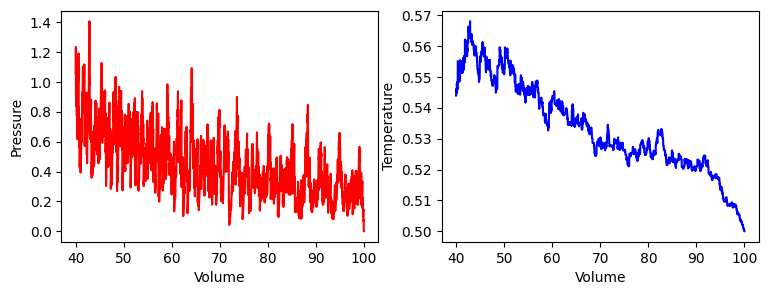

In [ ]:
num_data = 5000

volumes = np.zeros(num_data, dtype=float)
pressures = np.zeros(num_data, dtype=float)
temperatures = np.zeros(num_data, dtype=float)
# times = np.linspace(1, 100, 100)

cv = ControlVolume(BOX_SIZE_0, BOX_SIZE_0, 50, 0.2 *  V_PISTON_0, 0.5)
for i in range(num_data):
    cv.take_time_step()
    volumes[i] = cv.area
    pressures[i] = cv.pressure
    temperatures[i] = cv.temperature

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.set_xlabel('Volume')
ax1.set_ylabel('Pressure')
ax2.set_xlabel('Volume')
ax2.set_ylabel('Temperature')
fig.tight_layout

ax1.plot(volumes, pressures, '-r')
ax2.plot(volumes, temperatures, '-b')

plt.show()

```{exercise}
Verifieer de uitkomst van deze testsimulatie en vergelijk de uitkomst met een vorig werkblad. Corrigeer de code als er vergissingen in zijn geslopen.
```

## Systeem van twee gekoppelde zuigers

Om nu een studie te doen naar de entropie van een systeem maken we gebruik van twee gekoppelde zuigers. Dit zijn twee zuigers genummerd '1' en '2' die samen een constant volume hebben, maar waarbij de beweging van de zuiger het ene volume verkleint en het andere volume evenveel vergroot. Dit systeem houden we voor de rest van dit weerkblad thermisch geïsoleerd ten opzichte van de omgeving, zodat we een goede boekhouding kunnen doen van de totale hoeveelheid energie. 

```{remark}
Als je heel precies kijkt, dan heeft elk volume in onze Pythoncode twee zuigers: één aan de linker en één aan de rechter kant van het volume. Wil je het beeld geheel kloppend hebben, dan moet je je voorstellen dat de twee volumes op het oppervlak van een cilinder zitten, waarbij de twee zuigers in tegengestelde richtingen bewegen. Beide zuigers verkleinen zo samen hetzelfde volume en maken de ander groter. 
```

### Isotherme verplaatsing

Als eerste kijken we naar het reversibele proces. We herhalen dat er geen thermisch contact is met de omgeving, maar er is wel thermisch contact tussen de twee volumes, zodat ze constant dezelfde temperatuur hebben. 

In de onderstaande code beginnen we met twee beheersvolumes `cv1` en `cv2`, die aan het begin hetzelfde volume $V_0$ hebben. Dan verplaatsen we de zuiger(s) met een constante snelheid naar het punt waar $V_1=\frac{1}{5}V_0$ en $V_2= \frac{9}{5} V_0$. Hieronder vind je het verloop van de druk en de temperatuur tijdens dit proces.

```{exercise}
Er stroomt gedurende dit experiment dus warmte tussen de twee beheersvolumes, waarom is het ondanks dit toch een reversibel proces?
```

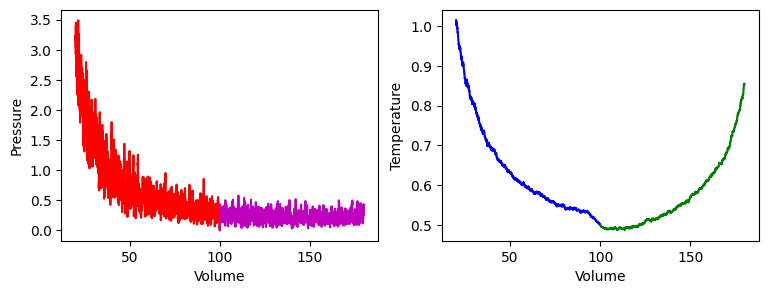

In [5]:
num_data = 6666

volumes1 = np.zeros(num_data, dtype=float)
pressures1 = np.zeros(num_data, dtype=float)
temperatures1 = np.zeros(num_data, dtype=float)
volumes2 = np.zeros(num_data, dtype=float)
pressures2 = np.zeros(num_data, dtype=float)
temperatures2 = np.zeros(num_data, dtype=float)

cv1 = ControlVolume(BOX_SIZE_0, BOX_SIZE_0, 50, +0.2 * V_PISTON_0, 0.5)
cv2 = ControlVolume(BOX_SIZE_0, BOX_SIZE_0, 50, -0.2 * V_PISTON_0, 0.5)

for i in range(num_data):
    cv1.take_time_step()
    cv2.take_time_step()
    average_temp = (cv1.temperature + cv2.temperature) / 2
    cv1.set_temp = average_temp
    cv2.set_temp = average_temp
    volumes1[i] = cv1.area
    pressures1[i] = cv1.pressure
    temperatures1[i] = cv1.temperature
    volumes2[i] = cv2.area
    pressures2[i] = cv2.pressure
    temperatures2[i] = cv2.temperature

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.set_xlabel('Volume')
ax1.set_ylabel('Pressure')
ax2.set_xlabel('Volume')
ax2.set_ylabel('Temperature')
fig.tight_layout

ax1.plot(volumes1, pressures1, '-r')
ax2.plot(volumes1, temperatures1, '-b')
ax1.plot(volumes2, pressures2, '-m')
ax2.plot(volumes2, temperatures2, '-g')

plt.show()

```{exercise}
Leg uit waarom de temperatuur van het systeem toeneemt als de zuiger een uitwijking krijgt ten opzichte van het midden. Leg daarna ook uit waarom deze toename in temperatuur steeds sneller gaat voor grotere uitwijking.
```

```{exercise}
Als je naar de temperatuur van de twee volumes kijkt (weergegeven in blauw en groen in de rechter grafiek), dan is deze telkens een beetje verschillend. Welke grootheid heeft de grootste invloed op dit verschil en waarom? (Verander de waardes in de simulatie om dit te onderzoeken en te controleren)
``` 

Dit systeem is zo gekozen dat het mogelijk is om de temperatuur analytisch te bepalen met behulp van een wiskundige afleiding. We gaan ervan uit dat het systeem bij de start helemaal symmetrisch is (zoals in de simulatie) en definiëren hierbij $x$ als de positie van de zuiger. Bij $x=-1$ staat de zuiger helemaal aan de kant van `cv1`, zodat $V_1=0$ en $V_2=2V_0$. Bij $x=+1$ staat de zuiger helemaal aan de andere kant, zodat $V_1=2V_0$ en $V_2=0$. 

Dan moet dus gelden dat:

$$
    V_1 = V_0 (1+x) \text{ en } V_2 = V_0 (1-x)
$$

Omdat ons gas twee vrijheidsgraden heeft wordt de interne energie van elk van de volumes ($i \in {1,2}$) gegeven door:

$$
    U_i = \frac{2}{2} N_i k_B T
$$

Met het aantal deeltjes aan beide kanten gelijk betekent dit voor de interne energie van het totale systeem

$$
    dU = dU_1 + dU_2 = 2N k_B dT
$$

Voor het verplaatsen van de zuiger geldt voor beide kanten:

$$
    \delta W_i = P_i dV_i = \frac{N k_B T}{V_i} dV_i.
$$

Als we deze twee formules samennemen dan levert dit:

$$
    -N k_B T \left( \frac{dV_1}{V_1} + \frac{dV_2}{V_2} \right) = 2 N k_b dT
$$

Vullen we de startformules voor $V_1$ en $V_2$ in, dan wordt dit:

$$
    \frac{dT}{dx} = \frac{x}{1-x^2}T.
$$

```{exercise}
In de bovenstaande afleiding is gebruik gemaakt van de relatie $dU=-\delta W$. Waarom kan je dat in dit geval stellen?
```

```{exercise}
Los de differentiaalvergelijking op en plot deze theoretisch voorspelling voor de temperatuur samen met het resultaat van de simulatie van hierboven.
(LET OP: Dit gaat dus niet om een fit, maar om een theoretische voorspelling die volledig gegeven wordt door de begincondities)
```

```{exercise}
Zie je afwijkingen tussen de theorie en de simulatie? Bespreek deze en leg uit waardoor ze worden veroorzaakt.
```

In [6]:
# Ruimte voor uitwerking

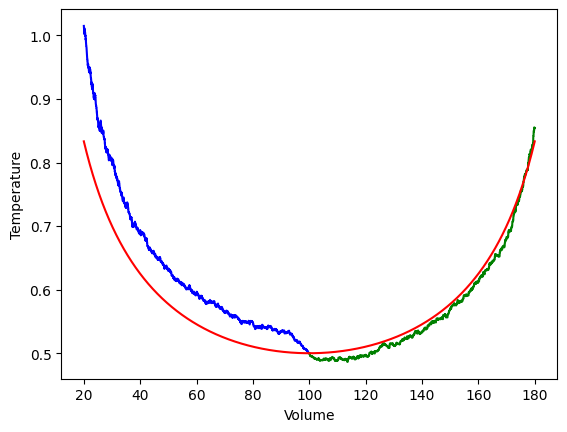

In [7]:
# voorbeeldantwoord

plt.figure()
plt.xlabel('Volume')
plt.ylabel('Temperature')

x_vals = np.linspace(-0.8, 0.8, num_data*2)
y_vals = 0.5 / np.sqrt(1 - x_vals**2)
x_vals = x_vals * 100 + 100

plt.plot(volumes1, temperatures1, '-b')
plt.plot(volumes2, temperatures2, '-g')
plt.plot(x_vals, y_vals, '-r')

plt.show()

Om te verifiëren dat dit proces reversibel is moeten we het proces ook terug kunnen uitvoeren. 

```{exercise}
Beweeg de zuiger terug en controleer de reversibiliteit van het proces
```

In [8]:
# ruimte voor uitwerking

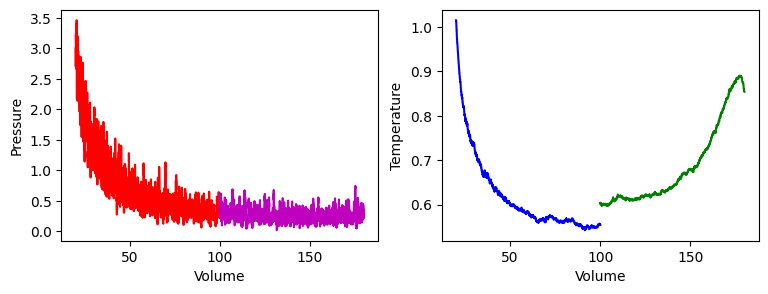

In [9]:
# voorbeelduitwerking

num_data = 6666

volumes1 = np.zeros(num_data, dtype=float)
pressures1 = np.zeros(num_data, dtype=float)
temperatures1 = np.zeros(num_data, dtype=float)
volumes2 = np.zeros(num_data, dtype=float)
pressures2 = np.zeros(num_data, dtype=float)
temperatures2 = np.zeros(num_data, dtype=float)

cv1.v_piston *= -1
cv2.v_piston *= -1
for i in range(num_data):
    cv1.take_time_step()
    cv2.take_time_step()
    average_temp = (cv1.temperature + cv2.temperature) / 2
    cv1.set_temp = average_temp
    cv2.set_temp = average_temp
    volumes1[i] = cv1.area
    pressures1[i] = cv1.pressure
    temperatures1[i] = cv1.temperature
    volumes2[i] = cv2.area
    pressures2[i] = cv2.pressure
    temperatures2[i] = cv2.temperature

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.set_xlabel('Volume')
ax1.set_ylabel('Pressure')
ax2.set_xlabel('Volume')
ax2.set_ylabel('Temperature')
fig.tight_layout

ax1.plot(volumes1, pressures1, '-r')
ax2.plot(volumes1, temperatures1, '-b')
ax1.plot(volumes2, pressures2, '-m')
ax2.plot(volumes2, temperatures2, '-g')

plt.show()

```{exercise}
Je ziet dat het proces terug niet helemaal overeenkomt. Beschrijf de verschillen en leg uit waar deze vandaan komen. Welk parameters kan je veranderen aan de simulatie om de reversibiliteit te verhogen? Zal het je lukken dit helemaal perfect te krijgen?

### Adiabatische verplaatsing zuiger

We kunnen in een vergelijkbare eindsituatie komen door de zuiger eerst adiabatisch te verplaatsen (dat wil zeggen: zonder onderling thermisch contact tussen de volumes) en pas daarna het thermische contact toe te staan. Om dat in onze simulatie te modelleren concentreren we ons eerst op de adiabatische verplaatsing van de zuigerwand en nemen we het thermische contact nog niet mee.

```{exercise}
Welke eindtemperatuur verwacht je na dit adiabatische proces voor de twee volumes als het om een ideaal gas gaat en we de zuiger net zoveel verplaatsen als in het vorige vorige experiment?
```

```{exercise}
En wat is dan de eindtemperatuur als we deze twee volumes in thermisch evenwicht laten komen?
```

```{exercise}
Maak een code voor een adabatische verplaatsing voor de zuigerwand van de positie $x=0$ naar de positie $x=-0.8$. Je kan hiervoor het best starten vanuit de code voor het isotherme proces en deze aanpassen.
```

In [10]:
# ruime voor uitwerking 
# kopieer hier eerst de code voor de isotherme simulatie

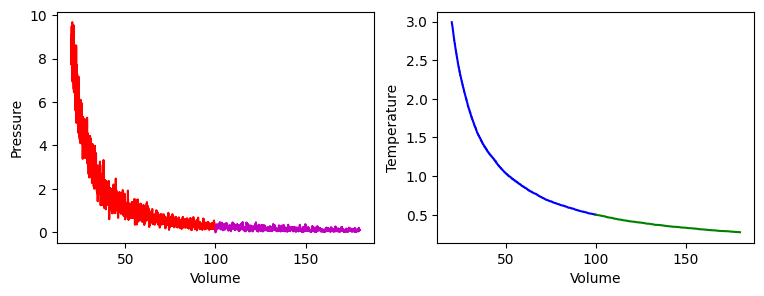

In [11]:
# voorbeeldantwoord

num_data = 6666

volumes1 = np.zeros(num_data, dtype=float)
pressures1 = np.zeros(num_data, dtype=float)
temperatures1 = np.zeros(num_data, dtype=float)
volumes2 = np.zeros(num_data, dtype=float)
pressures2 = np.zeros(num_data, dtype=float)
temperatures2 = np.zeros(num_data, dtype=float)

cv1 = ControlVolume(BOX_SIZE_0, BOX_SIZE_0, 50, +0.2 * V_PISTON_0, -0.5)
cv2 = ControlVolume(BOX_SIZE_0, BOX_SIZE_0, 50, -0.2 * V_PISTON_0, -0.5)

for i in range(num_data):
    cv1.take_time_step()
    cv2.take_time_step()
    average_temp = (cv1.temperature + cv2.temperature) / 2
    volumes1[i] = cv1.area
    pressures1[i] = cv1.pressure
    temperatures1[i] = cv1.temperature
    volumes2[i] = cv2.area
    pressures2[i] = cv2.pressure
    temperatures2[i] = cv2.temperature

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.set_xlabel('Volume')
ax1.set_ylabel('Pressure')
ax2.set_xlabel('Volume')
ax2.set_ylabel('Temperature')
fig.tight_layout

ax1.plot(volumes1, pressures1, '-r')
ax2.plot(volumes1, temperatures1, '-b')
ax1.plot(volumes2, pressures2, '-m')
ax2.plot(volumes2, temperatures2, '-g')

plt.show()

Na de adiabatische verplaatsing is het tijd om de twee volumes alsnog in thermisch evenwicht te brengen. Dat doen we met de code hieronder. 

```{exercise}
In deze code worden de waarden van de meetpunten niet opgeslagen in een array (geïnitialiseerd met de code `arraynaam = np.zeros(aantal_punten, data_type)`), maar als lijst. Waarom kiezen we nu voor deze vorm?
```

```{exercise}
Als je kritisch naar de code kijkt staan de twee volumes helemaal niet in thermisch contact met elkaar, maar gebeurt er iets anders. Omschrijf dat proces.
```

```{exercise}
Het antwoord laat zien dat de reactie van de twee volumes een verschillende karakteristieke tijd hebben. Waardoor wordt dit veroorzaakt?
Hint: stel je hiervoor de stuiterende balletjes voor.
```

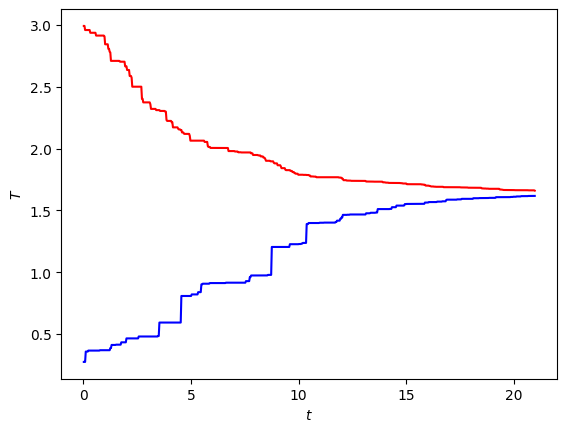

In [12]:
times = []
temp1 = []
temp2 = []

average_temp = (cv1.temperature + cv2.temperature) / 2
cv1.set_temp = average_temp
cv2.set_temp = average_temp
cv1.v_piston = 0.0
cv2.v_piston = 0.0
time = 0.0
while cv2.temperature < 0.99 * cv2.set_temp:
    time += DT
    cv1.take_time_step()
    cv2.take_time_step()
    temp1.append(cv1.temperature)
    temp2.append(cv2.temperature)
    times.append(time)

plt.figure()
plt.xlabel('$t$')
plt.ylabel('$T$')


plt.plot(times, temp1, '-r')
plt.plot(times, temp2, 'b-')

plt.show()




### Vergelijk van de twee experimenten

We hebben de zuiger dus in twee experimenten verschoven: 

- We begonnen in toestand 0, waarbij de zuiger in het midden stond en zijn isotherm naar toestand 1 bewogen. Tijdens dit proces stonden de volumes in constant thermisch contact.
- We begonnen in toestand 0 en verplaatsen de zuiger zonder thermisch contact (adiabatisch) naar toestand 2. Waarna we de twee volumes in thermisch contact brachten en zonder volumeverandering naar evenwicht kwamen in toestand 3.   

Uit de thermodynamische formules en uit de simulatie kan je concluderen dat de eindtemperatuur na deze twee experimenten verschillend is. Omdat we het systeem nooit in thermisch contact met de omgeving hebben gebracht, moet de energie hiervoor uit de arbeid komen die de zuigerwand heeft verricht. Dit laat zien dat de arbeid, die nodig is van de ene in de andere toestand te komen, afhankelijk is van het gekozen proces.

Een reversibele route is dan het 'goedkoopste' proces om in een toestand te komen. Voor het experiment zou het perfect uitgevoerde isotherme proces reversibel zijn en daarom de laagste temperatuur opleveren bij $x=-0.8$.

```{exercise}
Bereken uit de thermodynamische formules hoeveel entropie er vrijkomt bij het tweede proces. 
Hint: Je mag hierbij uitgaan van een constante soortelijke warmte als functie van temperatuur. 
```

```{exercise}
Laat zien dat deze entropie precies overeenkomt met de verhouding van de eindtemperatuur na de twee omschreven processen. 
```

Als we ons beperken tot het thermisch geïsoleerde systeem is er een deel van de uitgevoerde arbeid verloren gegaan en verplaatst naar de interne energie. Die arbeid is niet meer beschikbaar, omdat de zuiger al in de laagste energietoestand zit. De verandering in entropie is een maat voor hoeveel arbeid dat is. 

```{remark}
Als het systeem oorspronkelijk (in toestand 0) de omgevingstemperatuur heeft, kan je na het tweede experiment alsnog energie halen uit het temperatuurverschil tussen het systeem en de omgeving. Dit proces wordt omschreven door de grootheid 'exergie' die wordt behandeld in hoofdstuk 7 van het boek. Dit is geen onderdeel van de stof van dit kwartaal. 
```

```{exercise}
Gebruik nu de gegevens uit de simulaties die je hierboven hebt gedraaid om dezelfde berekening te doen. Wat verandert er ten opzichte van de theorie en waardoor komt dit? 
```

